In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
Image.LOAD_TRUNCATED_IMAGES = True
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Define paths to our dataset
train_path = "FaceShape Dataset/training_set"
test_path = "FaceShape Dataset/testing_set"

# Get all face shape categories
categories = os.listdir(train_path)
categories = [c for c in categories if c != 'desktop.ini']
print("Face shape categories:", categories)

# Count images in each category
print("\nTraining set:")
for category in categories:
    count = len(os.listdir(os.path.join(train_path, category)))
    print(f"  {category}: {count} images")

print("\nTesting set:")
for category in categories:
    count = len(os.listdir(os.path.join(test_path, category)))
    print(f"  {category}: {count} images")

Face shape categories: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']

Training set:
  Heart: 800 images
  Oblong: 800 images
  Oval: 800 images
  Round: 800 images
  Square: 800 images

Testing set:
  Heart: 200 images
  Oblong: 200 images
  Oval: 200 images
  Round: 201 images
  Square: 200 images


Heart (286, 350)
Oblong (684, 821)
Oval (1557, 1949)
Round (265, 336)
Square (439, 585)


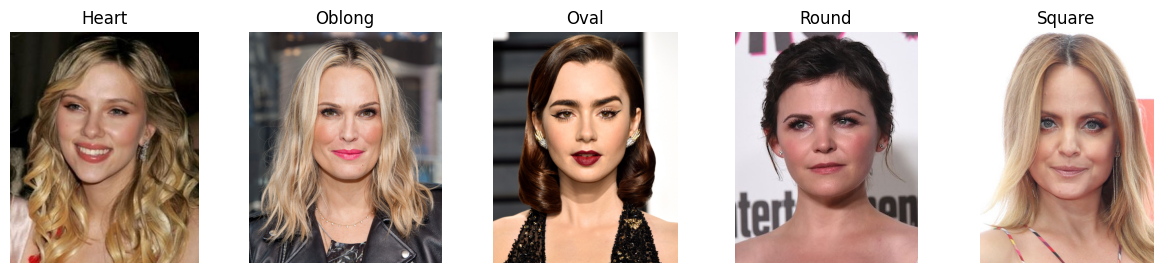

In [3]:
plt.figure(figsize=(15,3))

for i,category in enumerate(categories):
    category_path = os.path.join(train_path, category)
    first_image = os.listdir(category_path)[0]
    img = Image.open(os.path.join(category_path, first_image))
    print(category, img.size)

    plt.subplot(1,5, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show()

In [4]:
print(img.size)

(439, 585)


In [5]:
def preprocess_image(image_path):
    try:
        img = Image.open(image_path)
        img = img.convert('RGB')
        img = img.resize((224, 224))
        img_np = np.array(img)
        img_np = img_np / 255.0
        return img_np
    except Exception as e:
        return None

In [6]:
heart_path = os.path.join(train_path, 'Heart')
first_image = os.listdir(heart_path)[0]
image_path = os.path.join(heart_path, first_image)

In [7]:
result = preprocess_image(image_path)
print(result.shape)
print(result.max())
print(result.min())

(224, 224, 3)
1.0
0.0


In [8]:
def load_dataset(folder_path):
    X = []
    y = []
    
    categories = os.listdir(folder_path)
    categories = [c for c in categories if c != 'desktop.ini']
    
    for category in categories:
        category_path = os.path.join(folder_path, category)
        images = os.listdir(category_path)
        
        for image_name in images:
            image_path = os.path.join(category_path, image_name)
            processed_image = preprocess_image(image_path)
            if processed_image is not None:
                X.append(processed_image)
                y.append(category)
    
    return X, y

In [9]:
print("Loading training data...")
X_train, y_train = load_dataset(train_path)
print(f"Training images loaded: {len(X_train)}")
print(f"Training labels loaded: {len(y_train)}")

Loading training data...
Training images loaded: 3998
Training labels loaded: 3998


In [10]:
print("Loading testing data...")
X_test, y_test = load_dataset(test_path)
print(f"Testing images loaded: {len(X_test)}")
print(f"Testing labels loaded: {len(y_test)}")

Loading testing data...
Testing images loaded: 1000
Testing labels loaded: 1000


In [11]:
X_train = np.array(X_train)
X_test = np.array(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3998, 224, 224, 3)
X_test shape: (1000, 224, 224, 3)


In [12]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

y_train_categorical = to_categorical(y_train_encoded, num_classes=5)
y_test_categorical = to_categorical(y_test_encoded, num_classes=5)

print("Classes:", le.classes_)
print("y_train shape:", y_train_categorical.shape)
print("y_test shape:", y_test_categorical.shape)

Classes: ['Heart' 'Oblong' 'Oval' 'Round' 'Square']
y_train shape: (3998, 5)
y_test shape: (1000, 5)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dense(512, activation='relu'),
    Dropout(0.5),
    
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           2,565 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,398,661 (169.37 MB)

 Trainable params: 44,398,661 (169.37 MB)

 Non-trainable params: 0 (0.00 B)